In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ili_df = pd.read_csv("tsf_compare/data/ili/national_illness.csv")
ili_df.head()

,date,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,OT
0,2002-01-01 00:00:00,1.22262,1.16668,582,805,2060,754,176569
1,2002-01-08 00:00:00,1.33344,1.21650,683,872,2267,785,186355
2,2002-01-15 00:00:00,1.31929,1.13057,642,878,2176,831,192469
3,2002-01-22 00:00:00,1.49484,1.25246,728,1045,2599,863,207512
4,2002-01-29 00:00:00,1.47195,1.30237,823,1189,2907,909,223208


In [3]:
ili_df.shape

(966, 8)

In [4]:
966//53

18

### Only using data of 25 days

In [5]:
df = ili_df.iloc[:18*53, 1:7]
df_raw = df.copy()
df.head()

,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS
0,1.22262,1.16668,582,805,2060,754
1,1.33344,1.21650,683,872,2267,785
2,1.31929,1.13057,642,878,2176,831
3,1.49484,1.25246,728,1045,2599,863
4,1.47195,1.30237,823,1189,2907,909


### Smoothing using rolling mean

In [6]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [7]:
import math

SPLIT_RATIO = 0.8
TOTAL_POINTS = len(df)
PERIOD = 18
TRAIN_DAYS = math.ceil(PERIOD * SPLIT_RATIO)
TEST_DAYS = PERIOD - TRAIN_DAYS
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")
print(f"Train days: {TRAIN_DAYS}, Test days: {TEST_DAYS}")

Tensor dimensions: 18 x 53 x 6
Train days: 15, Test days: 3


In [8]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(18, 53, 6)

In [9]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (15, 53, 6)
Test tensor shape: (3, 53, 6)


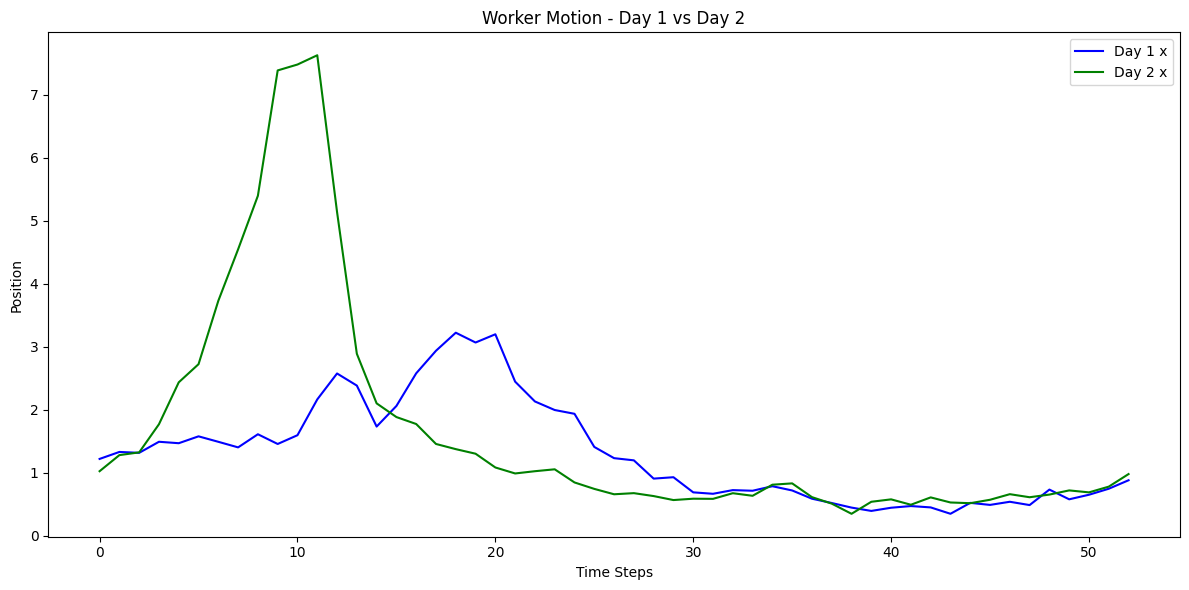

In [10]:
train_day_1 = tensor[0, :, :]
train_day_2 = tensor[1, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [11]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (15, 2)
Time factors shape: (53, 2)
Feature factors shape: (6, 2)


In [12]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (15, 53, 6)
Reconstructed tensor shape: (15, 53, 6)


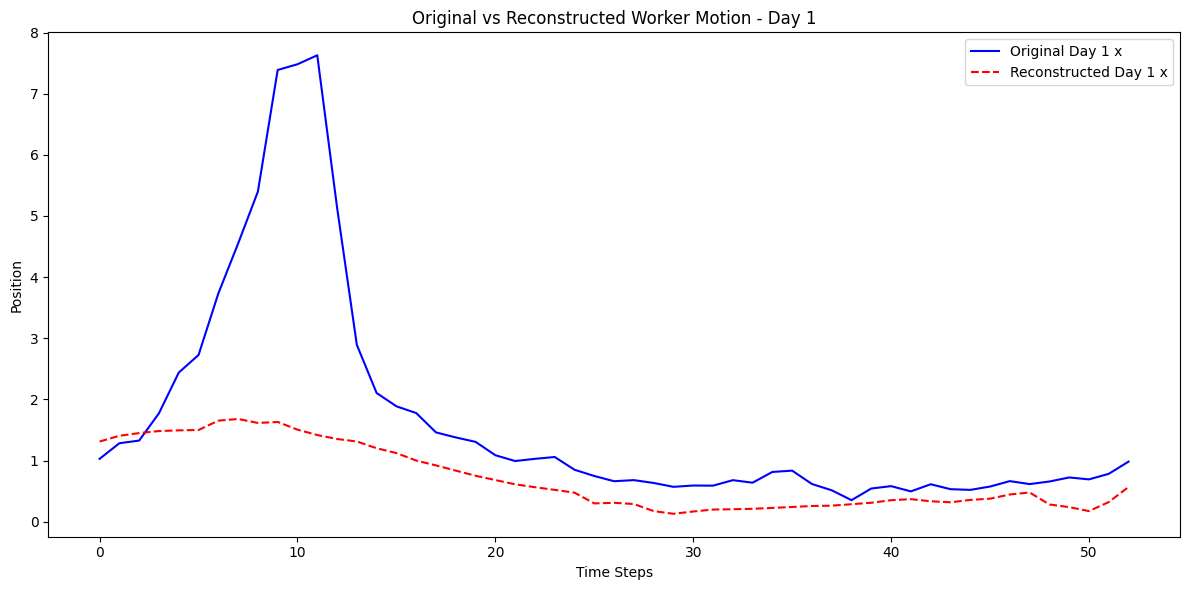

In [13]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [14]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

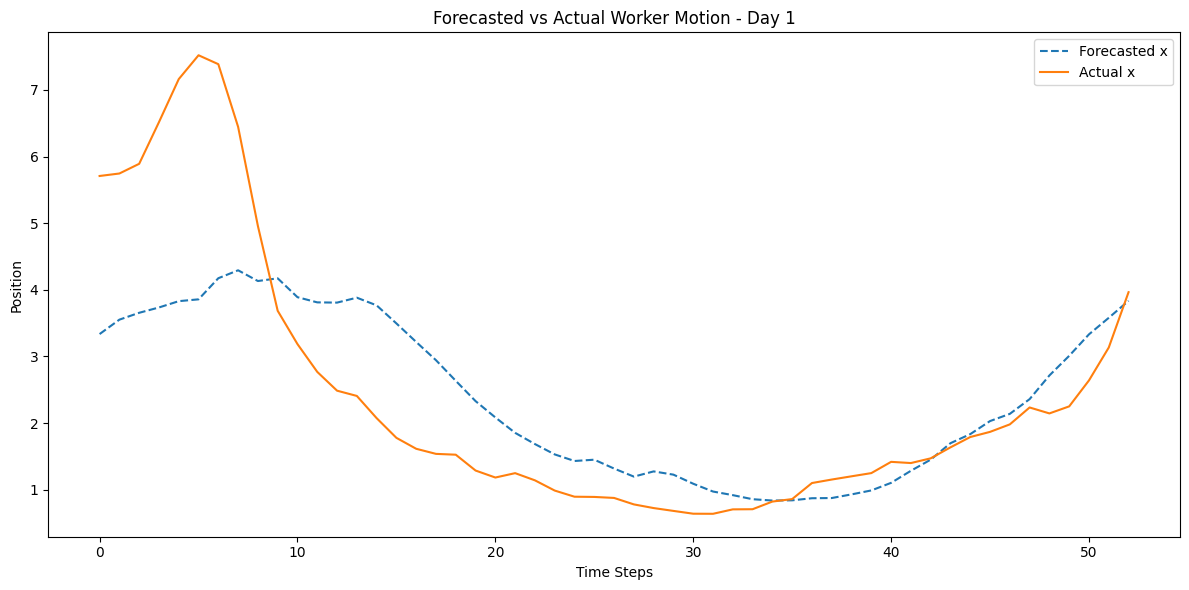

In [15]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

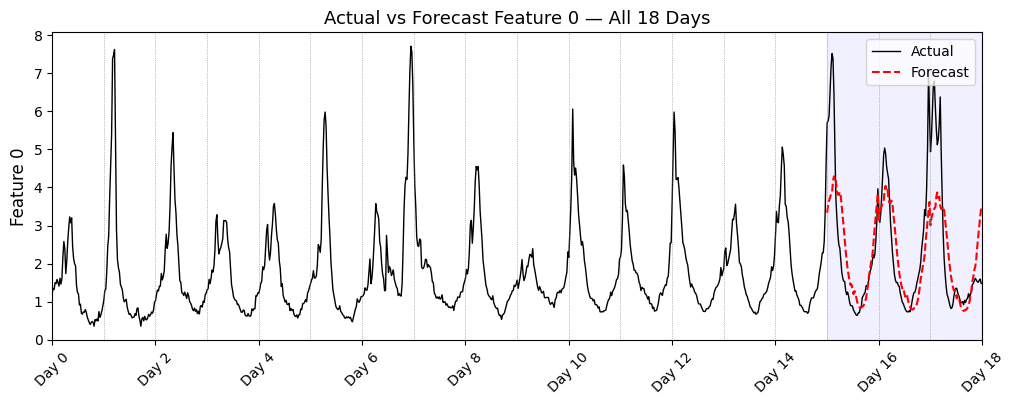

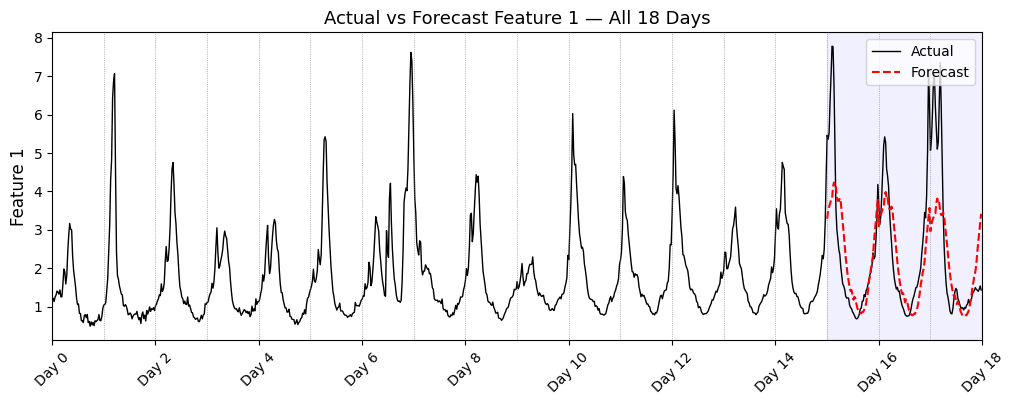

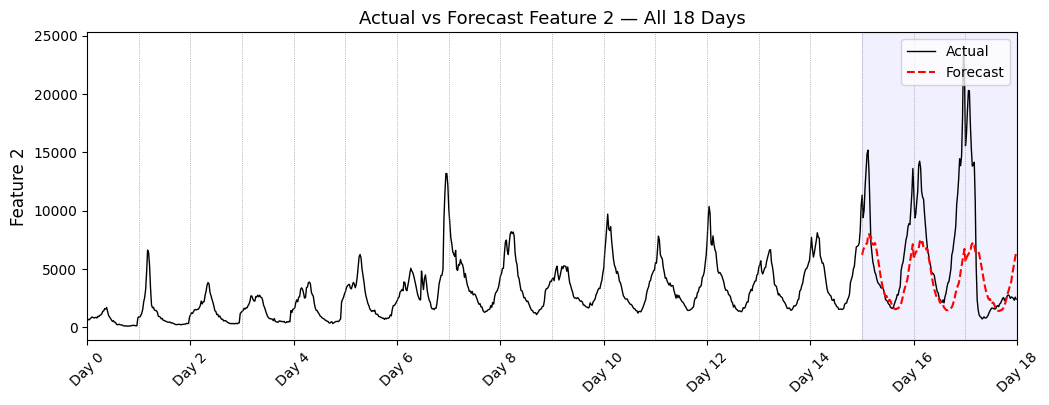

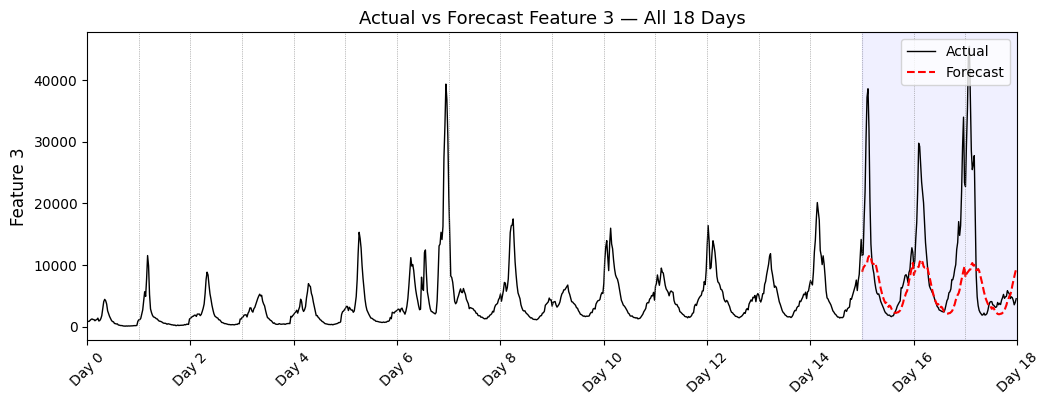

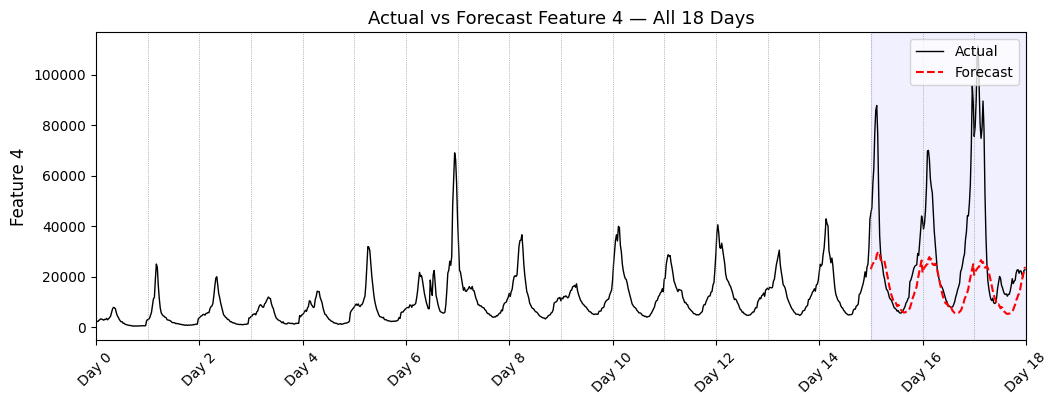

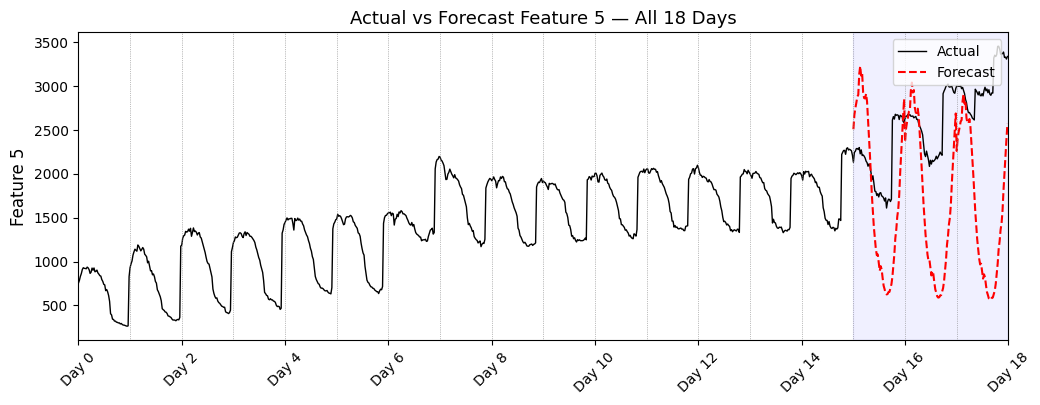

In [16]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

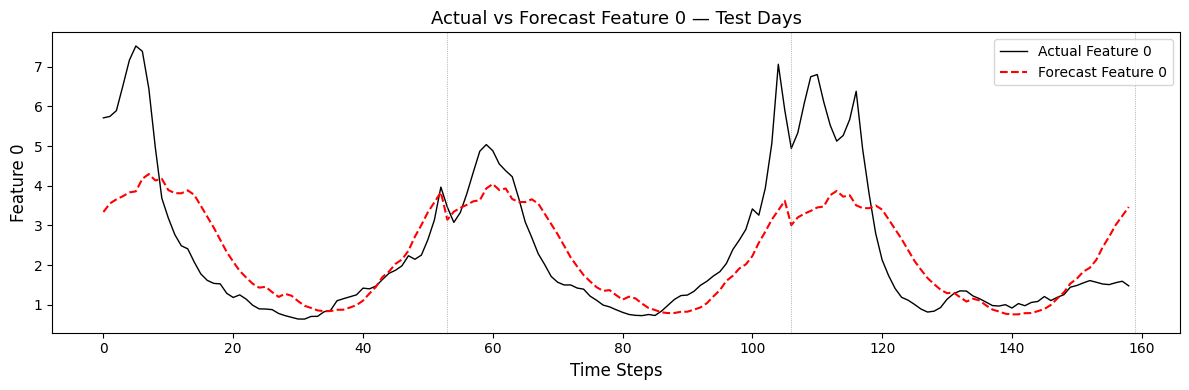

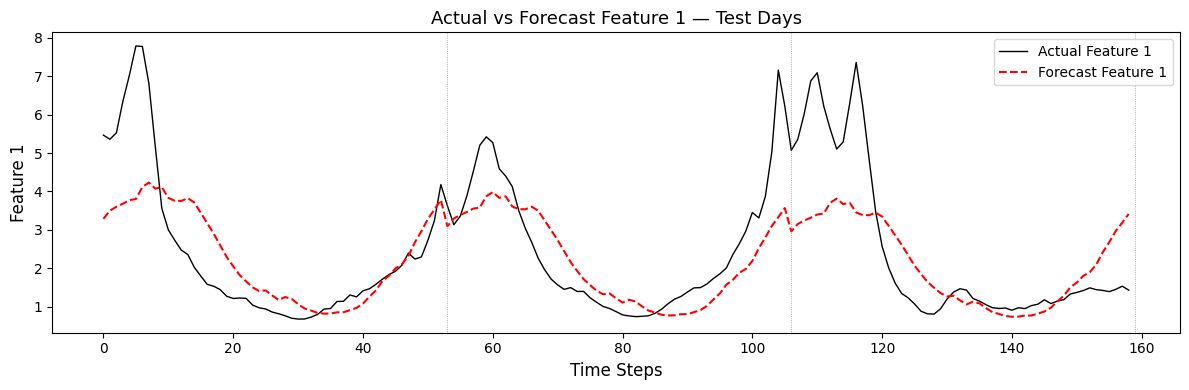

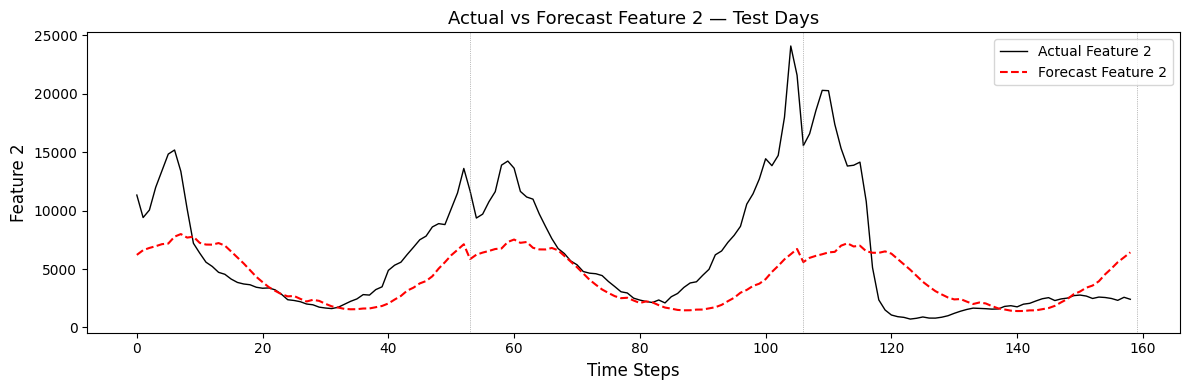

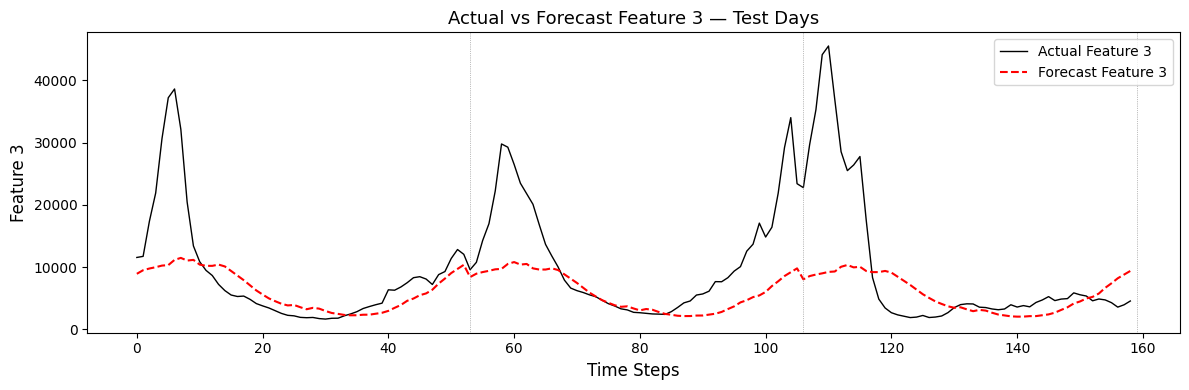

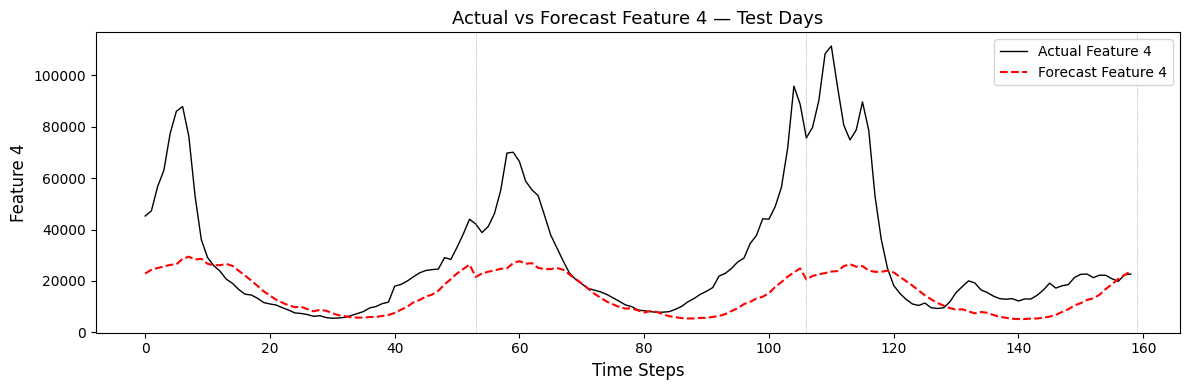

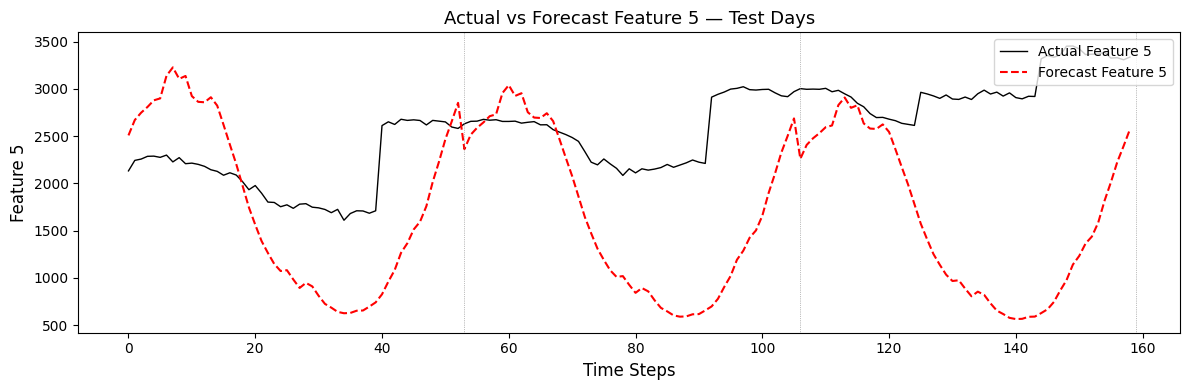

In [17]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [18]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((795, 6), (159, 6))

In [19]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    print(f"R² Score for Feature {i}: {r2:.4f}")


R² Score for Feature 0: 0.5757
R² Score for Feature 1: 0.5517
R² Score for Feature 2: 0.1974
R² Score for Feature 3: 0.1595
R² Score for Feature 4: 0.0152
R² Score for Feature 5: -6.0950
